In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv('corporate_dataset.csv')
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
0,CORP-06613,Financial Services,China,2029,0.4987,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29
1,CORP-01597,Agriculture,Germany,2032,0.5213,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37
2,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26
3,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21
4,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16


In [2]:
# 1. Aggregate metrics by industry
# Calculating Total Investment, and Average gains for the business outcomes
industry_summary = df.groupby('industry').agg(
    total_investment=('ai_investment_usd', 'sum'),
    avg_revenue_impact=('revenue_impact', 'mean'),
    avg_cost_savings=('cost_savings', 'mean'),
    avg_productivity_gain=('productivity_gain', 'mean')
).sort_values(by='total_investment', ascending=False).reset_index()

# 2. Convert values to Millions (USD) and Percentages (%) for better readability
industry_summary['total_investment_m'] = industry_summary['total_investment'] / 1e6
industry_summary['avg_revenue_impact_m'] = industry_summary['avg_revenue_impact'] / 1e6
industry_summary['avg_cost_savings_m'] = industry_summary['avg_cost_savings'] / 1e6
industry_summary['avg_productivity_gain_pct'] = industry_summary['avg_productivity_gain'] * 100

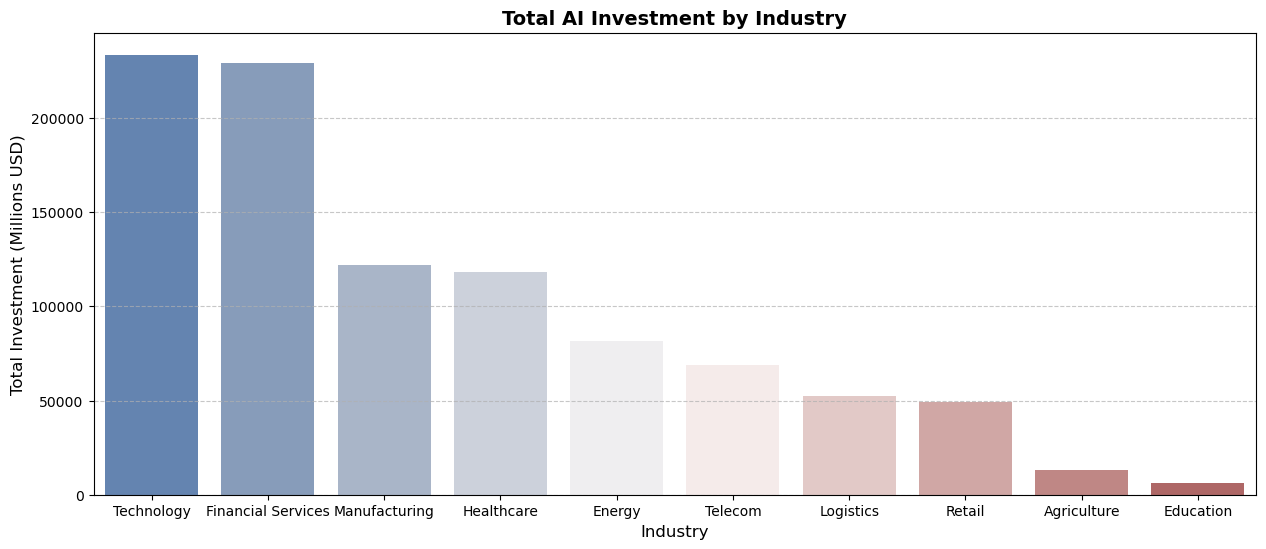

In [3]:
#Plot 1: Total AI Investment
plt.figure(figsize=(15,6))
sns.barplot(
    y='total_investment_m', 
    x='industry',
    data=industry_summary, 
    palette='vlag', legend=False, hue='industry'
)
plt.title('Total AI Investment by Industry', fontsize=14, fontweight='bold')
plt.ylabel('Total Investment (Millions USD)', fontsize=12)
plt.xlabel('Industry', fontsize=12)
plt.grid(axis='y', alpha=0.7, linestyle='--')
plt.show()

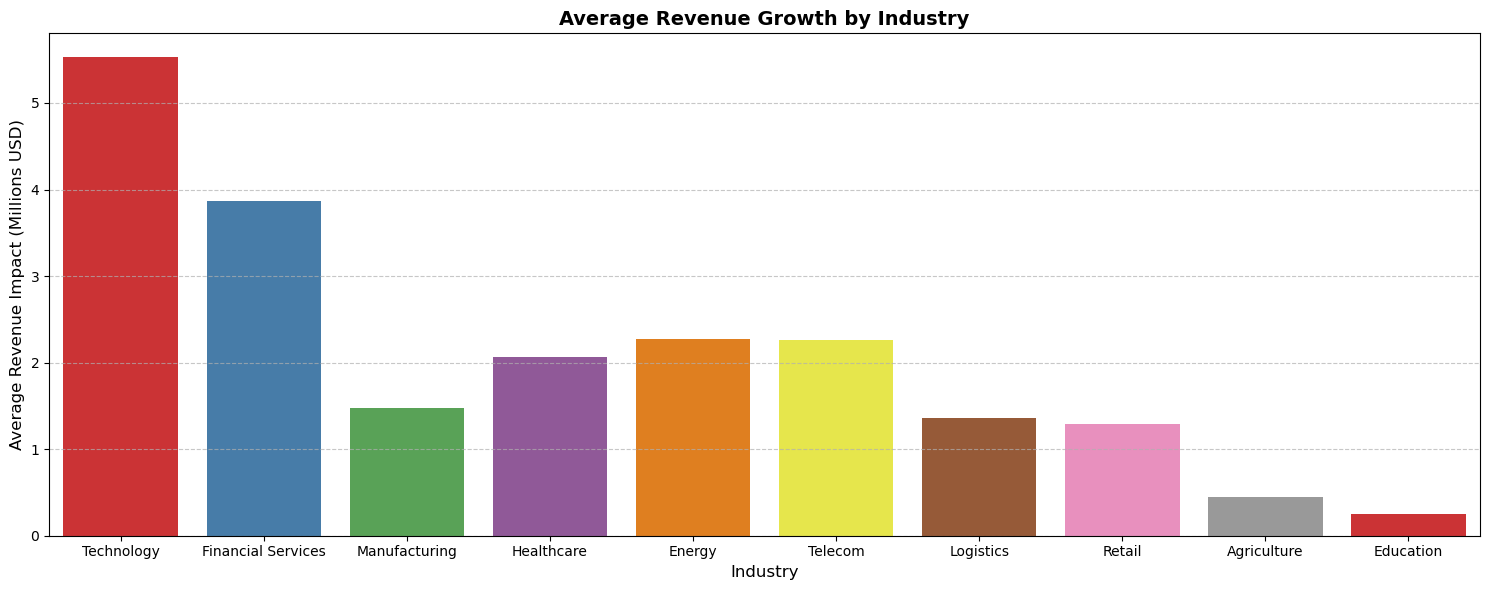

In [4]:
# Plot 2: Average Revenue Growth (Impact)
plt.figure(figsize=(15,6))
sns.barplot(
    y='avg_revenue_impact_m', 
    x='industry', 
    data=industry_summary, 
    palette='Set1', legend=False, hue='industry'
)
plt.title('Average Revenue Growth by Industry', fontsize=14, fontweight='bold')
plt.ylabel('Average Revenue Impact (Millions USD)', fontsize=12)
plt.xlabel('Industry', fontsize=12)
plt.grid(axis='y', alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

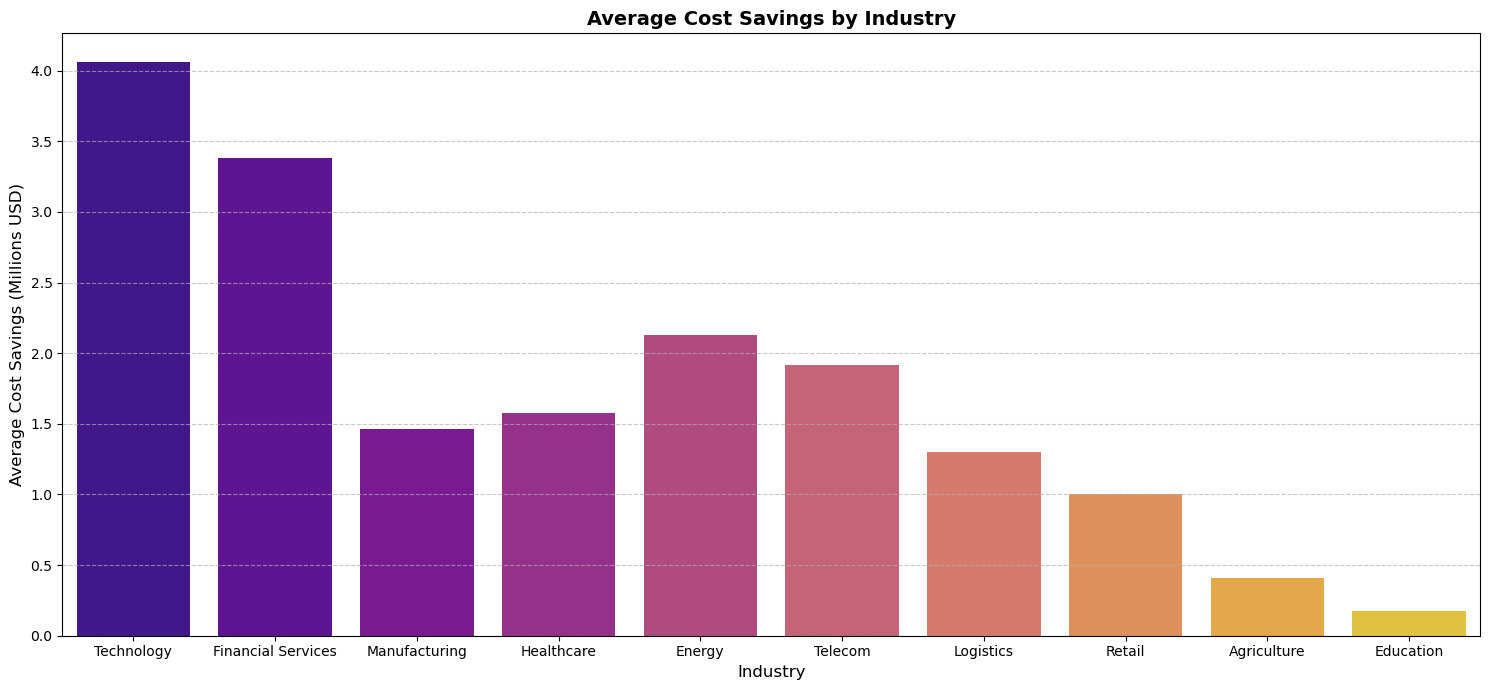

In [5]:
# Plot 3: Average Cost Savings
plt.figure(figsize=(15,7))
sns.barplot(
    y='avg_cost_savings_m', 
    x='industry', 
    data=industry_summary, 
    palette='plasma', legend=False, hue='industry'
)
plt.title('Average Cost Savings by Industry', fontsize=14, fontweight='bold')
plt.ylabel('Average Cost Savings (Millions USD)', fontsize=12)
plt.xlabel('Industry', fontsize=12)
plt.grid(axis='y', alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

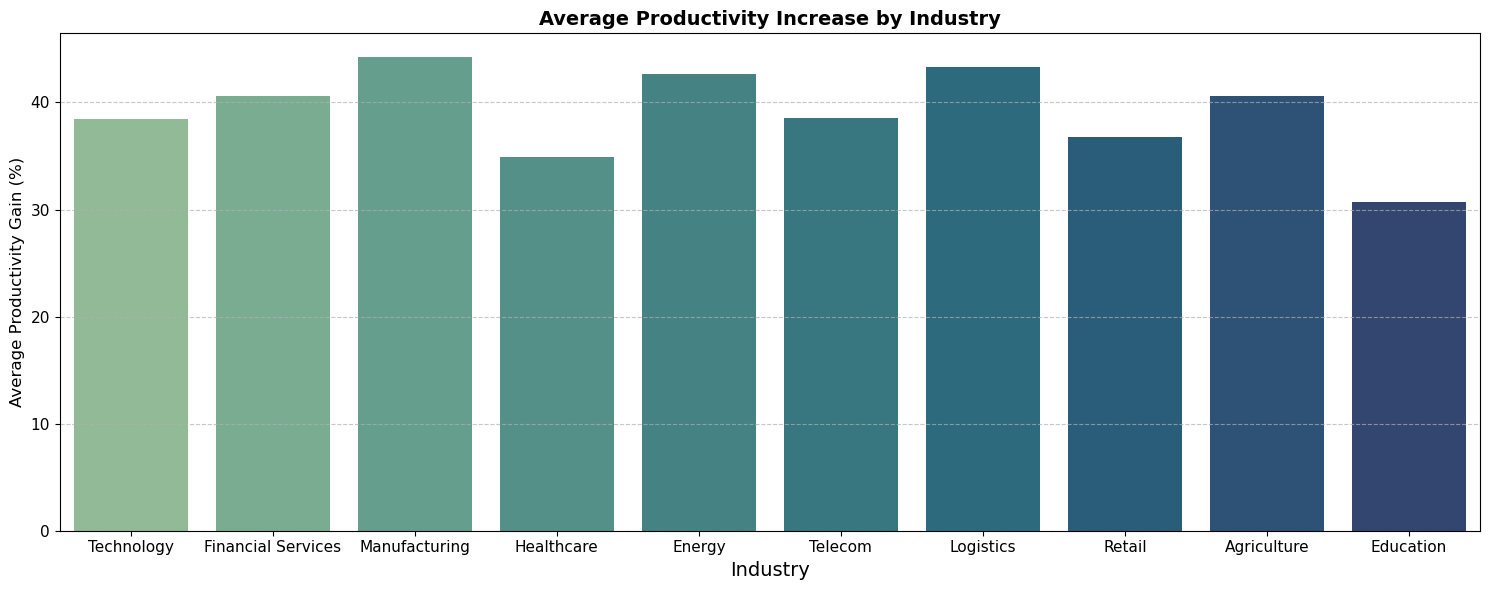

In [6]:
# Plot 4: Average Productivity Increase
plt.figure(figsize=(15,6))
sns.barplot(
    y='avg_productivity_gain_pct', 
    x='industry', 
    data=industry_summary, 
    palette='crest', legend=False, hue='industry'
)
plt.title('Average Productivity Increase by Industry', fontsize=14, fontweight='bold')
plt.ylabel('Average Productivity Gain (%)', fontsize=12)
plt.xlabel('Industry', fontsize=14)
plt.grid(axis='y', alpha=0.7, linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

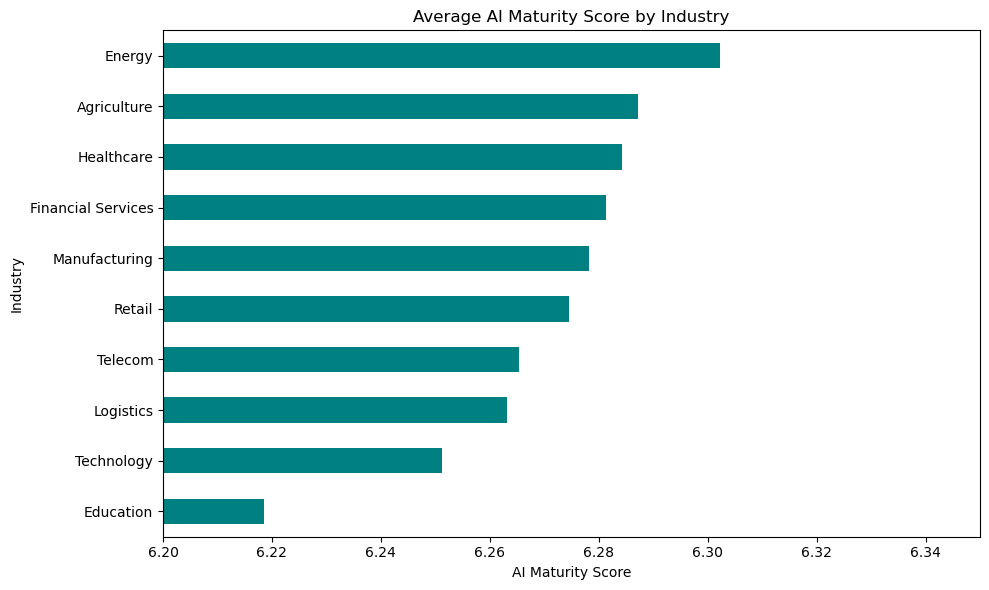

In [23]:
#5.AI Maturity Score
plt.figure(figsize=(10,6))

industry_maturity.sort_values().plot(
    kind='barh',
    color='teal'
)

plt.xlim(6.20, 6.35)

plt.title("Average AI Maturity Score by Industry")
plt.xlabel("AI Maturity Score")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

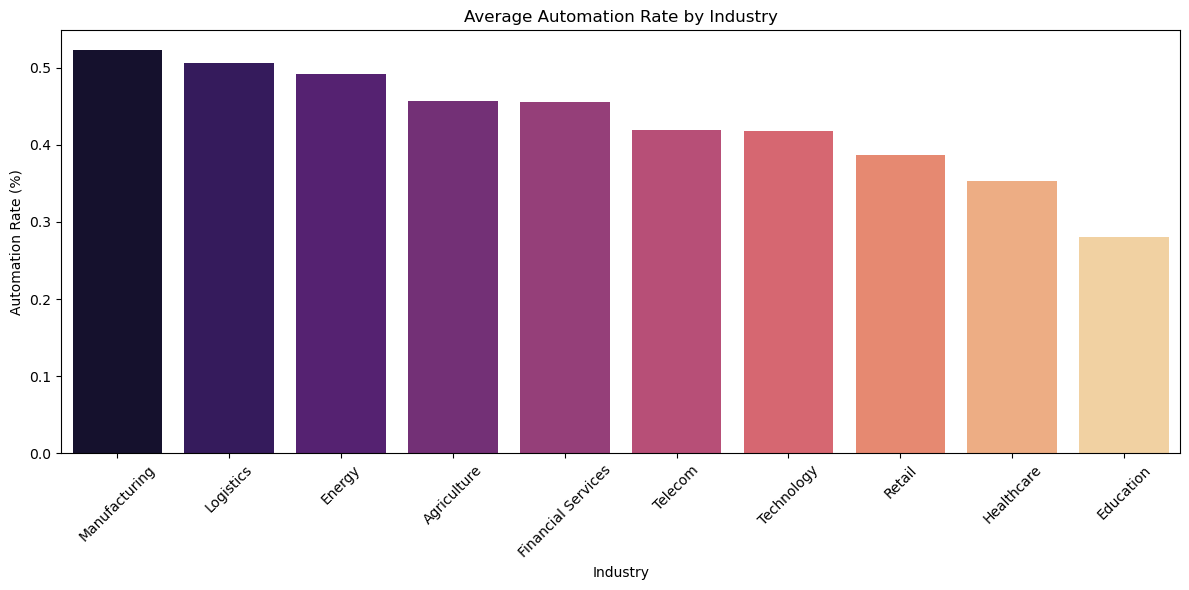

In [24]:
#6.Automation Rate
industry_automation = df.groupby("industry")["automation_rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=industry_automation.index,
    y=industry_automation.values,
    hue=industry_automation.index,
    palette="magma",
    legend=False
)

plt.title("Average Automation Rate by Industry")
plt.xlabel("Industry")
plt.ylabel("Automation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()